In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/DGS10.csv')

In [7]:
df.head()

,DGS10,delta,delta_bps
observation_date,,,
2021-03-24,1.62,NaN,NaN
2021-03-25,1.63,0.01,1.0
2021-03-26,1.67,0.04,4.0
2021-03-29,1.73,0.06,6.0
2021-03-30,1.73,0.00,0.0


In [13]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1305 entries, 2021-03-24 to 2026-03-24
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   DGS10      1250 non-null   float64
 1   delta      1194 non-null   float64
 2   delta_bps  1194 non-null   float64
dtypes: float64(3)
memory usage: 40.8 KB


In [4]:
# handle datetime index

df['observation_date'] = pd.to_datetime(df['observation_date'])
df.set_index('observation_date', inplace=True)
df.sort_index(inplace=True)

In [6]:
# compute the delta to remove stationarity

df['delta'] = df['DGS10'].diff()
df['delta_bps'] = df['delta'] * 100

In [8]:
# test for stationarity

from statsmodels.tsa.stattools import adfuller

res = adfuller(df['delta_bps'].dropna())
print(f'ADF Statistic: {res[0]:.4f}')
print(f'p-value: {res[1]:.4f}')

ADF Statistic: -25.9811
p-value: 0.0000


In [9]:
# for illustration: ADFuller on the actual yields should be non-stationary

res = adfuller(df['DGS10'].dropna())
print(f'ADF Statistic: {res[0]:.4f}')
print(f'p-value: {res[1]:.4f}')


ADF Statistic: -1.5419
p-value: 0.5127


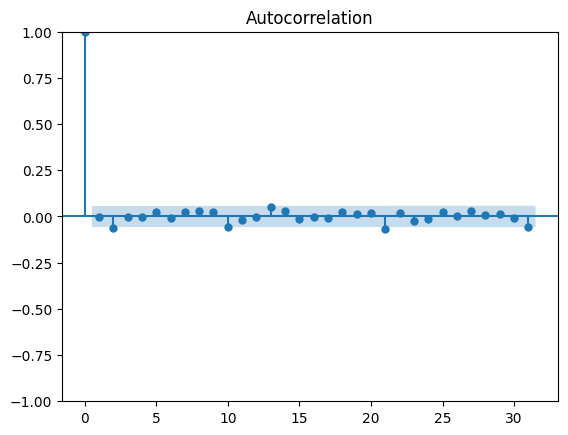

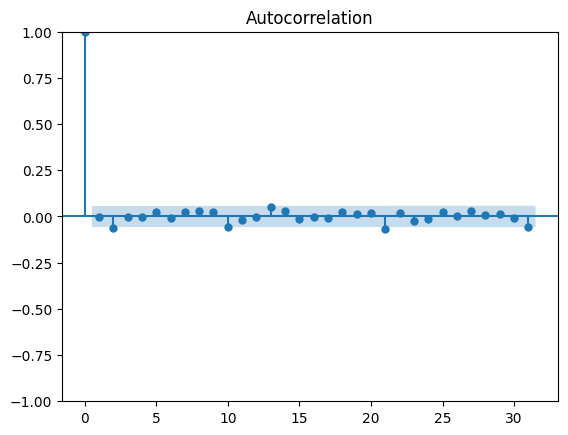

In [11]:
# ACF plots

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['delta_bps'].dropna())

Sample entropy parameters
- Embedding dimension: m=2 or 3 is commonly used.
- Tolerance: r ≈ 0.2×std(x) is a typical default.

In [17]:
# measure the sample antropy of our series

import antropy as ant 
import numpy as np 

sigma = np.std(df['DGS10'])

sample_entropy = ant.sample_entropy(df['delta_bps'], order=2, tolerance=0.2*sigma)
print(f'Sample Entropy: {sample_entropy}')


Sample Entropy: 1.6235047594144547
